In [3]:
import pandas as pd
df=pd.read_csv("bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

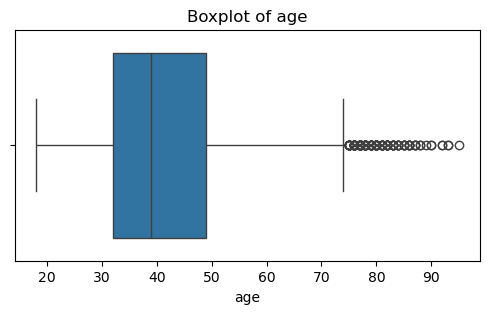

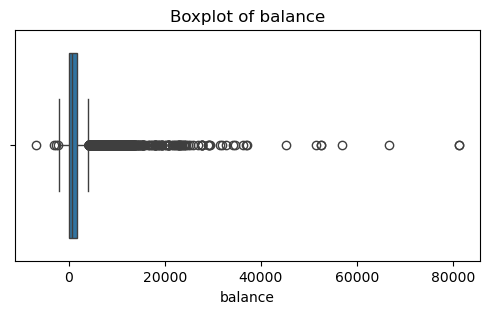

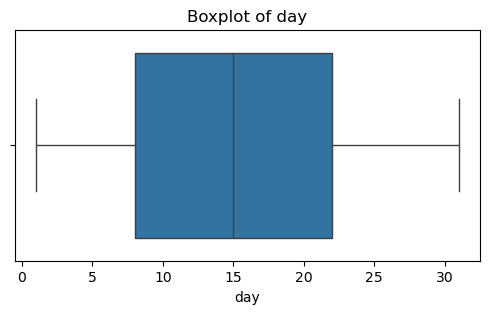

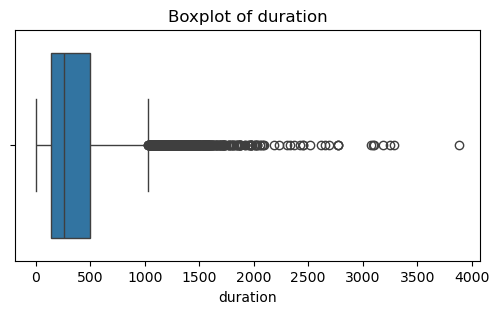

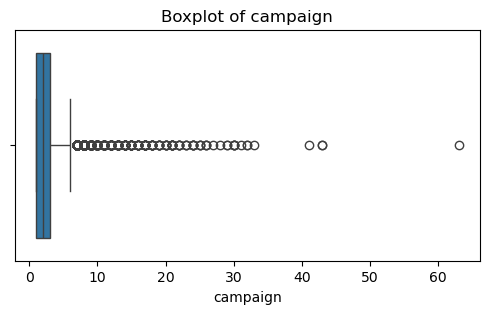

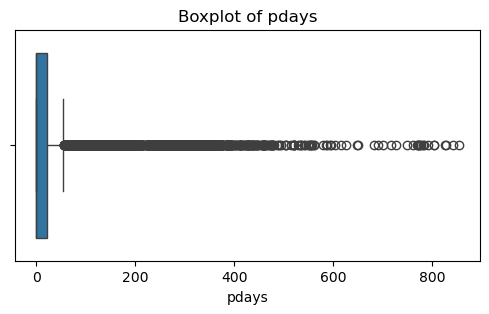

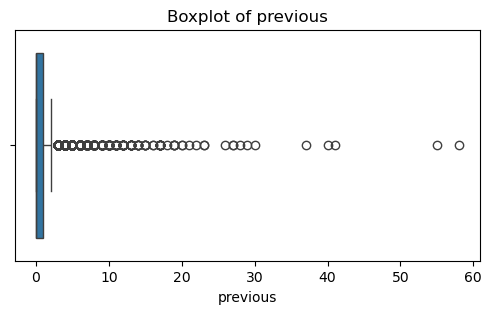

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [9]:
from scipy.stats import ttest_ind
import pandas as pd

numerical_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

results = []

for col in numerical_cols:

    yes = df[df['deposit']=='yes'][col]
    no = df[df['deposit']=='no'][col]

    t_stat, p_value = ttest_ind(yes, no)

    results.append({
        'Feature': col,
        'T Statistic': round(t_stat,4),
        'P Value': p_value,
        'Conclusion': 'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'
    })

ttest_results = pd.DataFrame(results)

ttest_results

,Feature,T Statistic,P Value,Conclusion
0,age,3.6892,2.260180e-04,Reject H0
1,balance,8.5988,9.126568e-18,Reject H0
2,day,-5.9598,2.602203e-09,Reject H0
3,duration,53.5180,0.000000e+00,Reject H0
4,campaign,-13.6429,4.831324e-42,Reject H0
5,pdays,16.2016,2.271607e-58,Reject H0
6,previous,14.9224,7.125338e-50,Reject H0


In [10]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

results = []

for col in categorical_cols:

    table = pd.crosstab(df[col], df['deposit'])

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        'Feature': col,
        'Chi Square': round(chi2,4),
        'P Value': p,
        'Conclusion': 'Reject H0' if p < 0.05 else 'Fail to Reject H0'
    })

chi_results = pd.DataFrame(results)

chi_results

,Feature,Chi Square,P Value,Conclusion
0,job,378.0753,2.741690e-74,Reject H0
1,marital,109.5834,1.600577e-24,Reject H0
2,education,122.7701,1.953419e-26,Reject H0
3,default,17.8086,2.442800e-05,Reject H0
4,housing,463.1892,9.724394e-103,Reject H0
5,loan,135.8322,2.171287e-31,Reject H0
6,contact,736.6867,1.072803e-160,Reject H0
7,month,1046.7745,1.642083e-217,Reject H0
8,poutcome,1004.6358,1.776185e-217,Reject H0


In [11]:
y=df["deposit"]

In [12]:
x=df.drop("deposit",axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols=x.select_dtypes(include="object").columns
for col in cat_cols:
    x[col]=x[col].astype(str)
    x[col]=le.fit_transform(x[col])

In [14]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int64
 2   marital    11162 non-null  int64
 3   education  11162 non-null  int64
 4   default    11162 non-null  int64
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int64
 7   loan       11162 non-null  int64
 8   contact    11162 non-null  int64
 9   day        11162 non-null  int64
 10  month      11162 non-null  int64
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  int64
dtypes: int64(16)
memory usage: 1.4 MB


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [16]:
x_train.shape

(8929, 16)

In [17]:
x_test.shape

(2233, 16)

In [18]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [19]:
df["deposit"].value_counts(normalize=True)*100

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)

y_sm.value_counts()

deposit
yes    4707
no     4707
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()

In [22]:
x_train_scaled = Scaler.fit_transform(x_train)

In [23]:
x_test_scaled=Scaler.transform(x_test)

In [24]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [25]:
lr.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred_lr=lr.predict(x_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_lr)

0.7899686520376176

In [28]:
train_score=lr.score(x_train_scaled,y_train)
train_score

0.7978497032142458

In [29]:
test_score=lr.score(x_test_scaled,y_test)
test_score

0.7899686520376176

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

          no       0.79      0.82      0.80      1166
         yes       0.79      0.76      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



In [31]:
from sklearn.svm import SVC
svc = SVC()

In [32]:
svc.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
y_pred_svc=svc.predict(x_test_scaled)

In [34]:
accuracy_score(y_test,y_pred_svc)

0.8132557098074339

In [35]:
train_score=svc.score(x_train_scaled,y_train)
train_score

0.8453354238996528

In [36]:
test_score=svc.score(x_test_scaled,y_test)
test_score

0.8132557098074339

In [37]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

          no       0.83      0.80      0.82      1166
         yes       0.79      0.83      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [39]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
y_pred_knn=knn.predict(x_test_scaled)

In [41]:
accuracy_score(y_test, y_pred_knn)

0.7733990147783252

In [42]:
train_score=knn.score(x_train_scaled,y_train)
train_score

0.8447754507783627

In [43]:
knn.score(x_test_scaled,y_test)

0.7733990147783252

In [44]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

          no       0.76      0.82      0.79      1166
         yes       0.79      0.72      0.75      1067

    accuracy                           0.77      2233
   macro avg       0.78      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



In [45]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [46]:
nb.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [47]:
y_pred_nb = nb.predict(x_test_scaled)

In [48]:
accuracy_score(y_test,y_pred_nb)

0.7465293327362292

In [49]:
nb.score(x_train_scaled,y_train)

0.7536118266323216

In [50]:
nb.score(x_test_scaled, y_test)

0.7465293327362292

In [51]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

          no       0.80      0.69      0.74      1166
         yes       0.70      0.81      0.75      1067

    accuracy                           0.75      2233
   macro avg       0.75      0.75      0.75      2233
weighted avg       0.75      0.75      0.75      2233



In [52]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [53]:
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
y_pred_dt=dt.predict(x_test)

In [55]:
accuracy_score(y_test,y_pred_dt)

0.7662337662337663

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


model = DecisionTreeClassifier()

param_dist = {
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}


random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)


random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 3}


In [57]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth= 8, min_samples_leaf= 4, min_samples_split= 3)

In [58]:
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,3
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred_dt=dt.predict(x_test)

In [60]:
accuracy_score(y_test,y_pred_dt)

0.8119122257053292

In [61]:
dt.score(x_train, y_train)

0.8523910852279091

In [62]:
dt.score(x_test, y_test)

0.8119122257053292

In [63]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

          no       0.81      0.83      0.82      1166
         yes       0.81      0.79      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [64]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [65]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf=rf.predict(x_test)

In [67]:
accuracy_score(y_test,y_pred_rf)

0.8325123152709359

In [68]:
rf.score(x_train,y_train)

0.999888005375742

In [69]:
rf.score(x_test,y_test)

0.8325123152709359

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


model = RandomForestClassifier()

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)


print("Best Parameters:", random_search.best_params_)

Best Parameters: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}


In [87]:
rf=RandomForestClassifier( n_estimators=99,max_depth= 14, min_samples_leaf=1, min_samples_split=5,random_state=34)

In [88]:
rf.fit(x_train,y_train)

,n_estimators,99
,criterion,'gini'
,max_depth,14
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
y_pred_rf=rf.predict(x_test)

In [90]:
accuracy_score(y_test,y_pred_rf)

0.8320644872369011

In [91]:
rf.score(x_train,y_train)

0.9428827416284018

In [92]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

          no       0.86      0.81      0.83      1166
         yes       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



In [2]:
import pandas as pd

# Final Classification Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVC",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],

    "Train Score": [
        0.80,
        0.85,
        0.84,
        0.75,
        0.85,
        0.94
    ],

    "Test Score": [
        0.79,
        0.81,
        0.77,
        0.75,
        0.81,
        0.83
    ],

    "Accuracy": [
        0.79,
        0.81,
        0.77,
        0.75,
        0.81,
        0.83
    ],

    "Recall": [
        0.76,
        0.84,
        0.86,
        0.77,
        0.79,
        0.85
    ],

    "F1-Score": [
        0.78,
        0.81,
        0.76,
        0.75,
        0.80,
        0.83
    ]
})

# Train-Test Gap
comparison["Gap"] = (
    comparison["Train Score"] -
    comparison["Test Score"]
).abs().round(2)

# Generalization
comparison["Generalization"] = [
    "Well Generalized",
    "Best Generalized ⭐",
    "Slight Overfit",
    "Underfitting",
    "Slight Overfit",
    "Overfitting"
]

# Bias-Variance
comparison["Bias-Variance"] = [
    "Balanced",
    "Balanced",
    "High Variance",
    "High Bias",
    "High Variance",
    "High Variance"
]

# Best Generalized Model
comparison["Best Generalized Model"] = [
    "No",
    "YES ⭐",
    "No",
    "No",
    "No",
    "No"
]

# Display final table
comparison

,Model,Train Score,Test Score,Accuracy,Recall,F1-Score,Gap,Generalization,Bias-Variance,Best Generalized Model
0,Logistic Regression,0.80,0.79,0.79,0.76,0.78,0.01,Well Generalized,Balanced,No
1,SVC,0.85,0.81,0.81,0.84,0.81,0.04,Best Generalized ⭐,Balanced,YES ⭐
2,KNN,0.84,0.77,0.77,0.86,0.76,0.07,Slight Overfit,High Variance,No
3,Naive Bayes,0.75,0.75,0.75,0.77,0.75,0.00,Underfitting,High Bias,No
4,Decision Tree,0.85,0.81,0.81,0.79,0.80,0.04,Slight Overfit,High Variance,No
5,Random Forest,0.94,0.83,0.83,0.85,0.83,0.11,Overfitting,High Variance,No
